**0. Import module yang diperlukan**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema visualisasi
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

**1. Membaca data**


> Silakan gunakan teknik membaca data teratas dan terbawah (cth: head(), tail()) yang tersedia pada pandas, atau teknik lainnya seperti describe()



In [2]:
# Membaca dataset
# Pastikan file dataset 'Housing.csv' sudah di-upload ke dalam direktori Google Colab/Jupyter
df = pd.read_csv('Housing.csv')

# Menampilkan 5 data teratas
print("5 Data Teratas:")
display(df.head())

# Menampilkan informasi dataset
print("\nInformasi Dataset:")
display(df.info())

# Menampilkan statistik deskriptif
print("\nStatistik Deskriptif:")
display(df.describe())

5 Data Teratas:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


None


Statistik Deskriptif:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Insight :

> Dataset ini memiliki 545 baris dan 13 kolom.

Target variabel kita adalah price (harga rumah), yang bertipe data numerik (int64).

Sebagian besar fitur bertipe object (kategorikal) seperti mainroad, guestroom, airconditioning, dan furnishingstatus. Data kategorikal ini perlu ditransformasi nanti agar bisa dibaca oleh algoritma Machine Learning.

Statistik deskriptif menunjukkan rentang harga rumah yang cukup besar, dengan harga minimal 1.750.000 dan maksimal 13.300.000.


**2. Cek Missing values dan duplicate pada data**
> Cek apakah ada missing values / duplicate pada data, jika ada perbaiki, jika tidak ada, berikan insight/penjelasan.

In [3]:
# Mengecek missing values
print("Total Missing Values per Kolom:")
display(df.isnull().sum())

# Mengecek data duplikat
duplicate_count = df.duplicated().sum()
print(f"\nJumlah Baris Duplikat: {duplicate_count}")

Total Missing Values per Kolom:


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0



Jumlah Baris Duplikat: 0


In [ ]:
# Write your code here

Insight :

> Berdasarkan pengecekan, dataset ini sangat bersih. Tidak ditemukan missing values (0 NaN di semua kolom) dan tidak ada data yang duplikat.

Kita bisa langsung melanjutkan ke tahap berikutnya tanpa perlu melakukan imputasi nilai atau menghapus baris duplikat.


**3. Hapus data jika ada duplicate dan isi missing values jika ada**

In [4]:
# Karena data sudah bersih, kita hanya membuat pipeline untuk berjaga-jaga
# Menghapus duplikat
df.drop_duplicates(inplace=True)

# Jika ada missing values di kolom numerik, kita bisa mengisinya dengan median (sebagai contoh)
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Jika ada missing values di kolom kategorikal, kita bisa mengisinya dengan modus
categorical_cols = df.select_dtypes(exclude=np.number).columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f"Bentuk data setelah pembersihan: {df.shape}")

Bentuk data setelah pembersihan: (545, 13)


In [ ]:
# Write your code here

Insight :

> Proses pembersihan data dieksekusi secara preventif. Karena sejak awal dataset tidak memiliki data duplikat maupun missing values, bentuk dataset (shape) tetap sama, yaitu (545, 13).


**4. Transformasi format**

> Cek dataset, apakah ada data yang bisa ditransformasi? (cth : yes or no menjadi 1 dan 0)

In [5]:
# 1. Transformasi kolom biner ('yes'/'no' menjadi 1/0)
binary_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_columns:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# 2. Transformasi kolom kategorikal multi-kelas ('furnishingstatus') menggunakan One-Hot Encoding
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# Cek hasil transformasi
display(df.head())
display(df.dtypes)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,int64
guestroom,int64
basement,int64
hotwaterheating,int64
airconditioning,int64


Insight :

> Semua kolom yang berisi teks 'yes' dan 'no' berhasil diubah menjadi bentuk biner 1 dan 0.

Kolom furnishingstatus (yang berisi furnished, semi-furnished, dan unfurnished) diubah menggunakan metode One-Hot Encoding. Drop_first=True digunakan untuk menghindari jebakan multikolinearitas (dummy variable trap), sehingga hanya menyisakan dua kolom baru: furnishingstatus_semi-furnished dan furnishingstatus_unfurnished.

Kini seluruh data berformat numerik atau boolean, siap untuk dianalisis lebih dalam.


**5. Laksanakan EDA (Exploratory Data Analysis)**

> Pada tahap ini, lakukan visualisasi data, dan eksplorasi serta analisis dataset yang diberikan sesuai EDA, lalu berikan setidaknya 3 insight dari dataset tersebut. Silakan tambah cell sebanyak - banyak yang diperlukan untuk keperluan EDA atau visualisasi data.

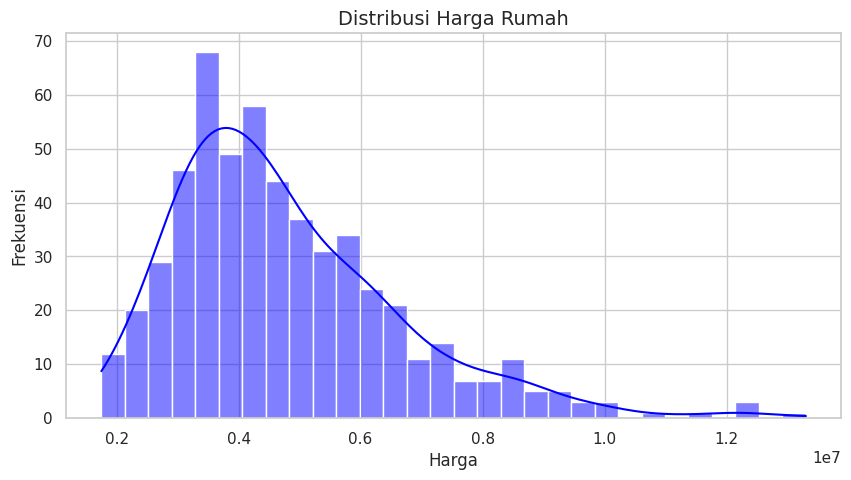

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=30, kde=True, color='blue')
plt.title('Distribusi Harga Rumah', fontsize=14)
plt.xlabel('Harga', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.show()

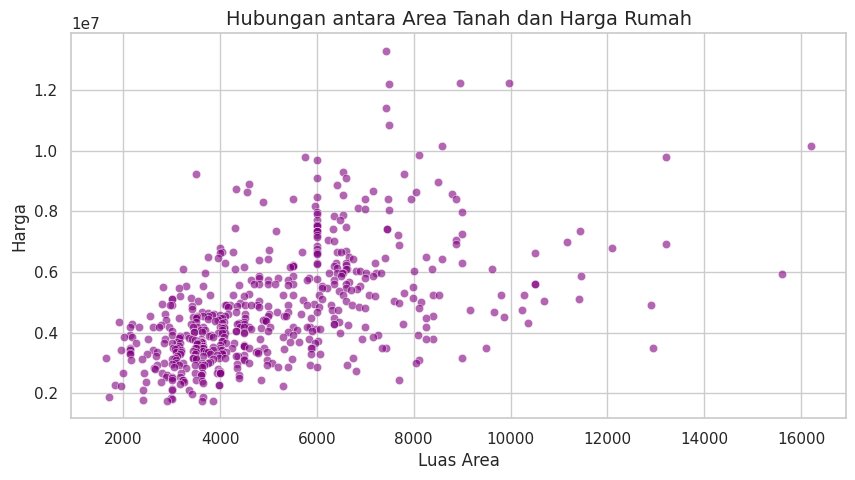

In [7]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='area', y='price', data=df, alpha=0.6, color='purple')
plt.title('Hubungan antara Area Tanah dan Harga Rumah', fontsize=14)
plt.xlabel('Luas Area', fontsize=12)
plt.ylabel('Harga', fontsize=12)
plt.show()

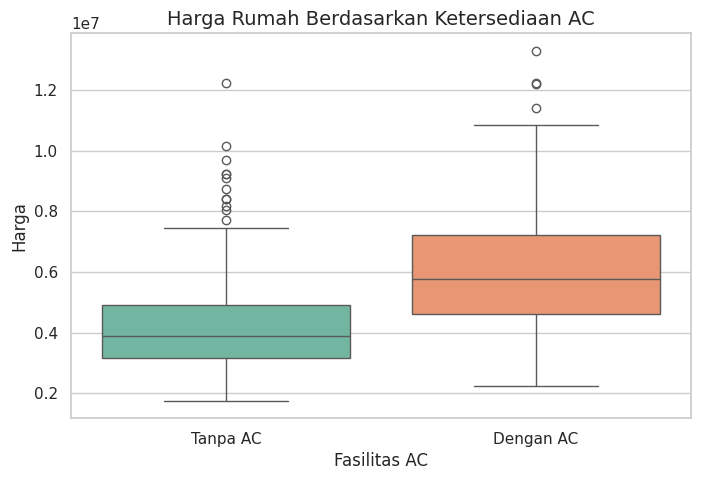

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='airconditioning', y='price', data=df, palette='Set2')
plt.title('Harga Rumah Berdasarkan Ketersediaan AC', fontsize=14)
plt.xticks([0, 1], ['Tanpa AC', 'Dengan AC'])
plt.xlabel('Fasilitas AC', fontsize=12)
plt.ylabel('Harga', fontsize=12)
plt.show()

Insight :

> Distribusi Harga (Target Variable): Distribusi harga rumah bersifat Right-Skewed (condong ke kanan). Ini wajar karena sebagian besar rumah berada di rentang harga menengah ke bawah, sementara hanya sedikit rumah "mewah" yang harganya sangat tinggi (ekor panjang di sebelah kanan).

Luas Area vs Harga: Terdapat korelasi positif linear antara luas area dan harga rumah. Secara umum, semakin besar luas tanah/bangunan, semakin tinggi harga yang ditawarkan, meskipun terdapat beberapa outliers (rumah dengan area kecil namun harganya mahal, mungkin karena faktor lokasi).

Pengaruh AC: Dari visualisasi boxplot, terlihat sangat jelas bahwa rumah yang dilengkapi dengan fasilitas pendingin ruangan (AC) memiliki median harga yang jauh lebih tinggi dibandingkan dengan rumah tanpa AC. Fasilitas ini sangat memengaruhi nilai jual properti.


**6. Correlation Matrix**

> Buat correlation matrix, transformasi dulu seluruh data ke numerik agar tidak error saat masuk ke correlation matrix. Lalu berikan insight, apa yang kamu temukan dari correlation matrix dataset tersebut?

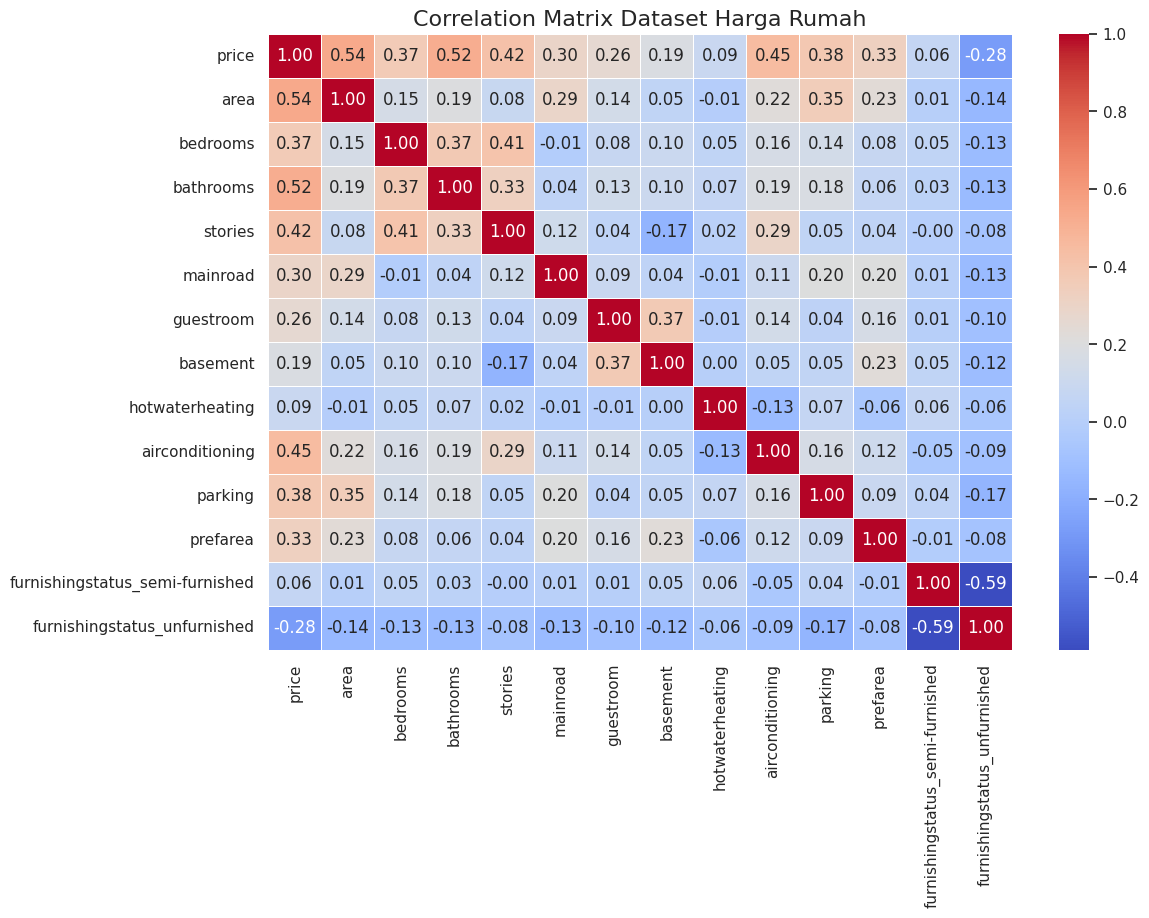

In [9]:
plt.figure(figsize=(12, 8))
# Menghitung korelasi antar fitur
corr_matrix = df.corr()

# Visualisasi dengan Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Dataset Harga Rumah', fontsize=16)
plt.show()

Insight :

> Variabel yang paling berkorelasi positif dengan price (harga) secara berurutan adalah: area (0.53), bathrooms (0.52), dan airconditioning (0.45). Hal ini menunjukkan bahwa luas rumah, jumlah kamar mandi, dan ketersediaan AC adalah penentu harga paling utama.

Sebaliknya, fitur furnishingstatus_unfurnished berkorelasi negatif (-0.28) dengan harga, yang berarti rumah yang tidak dilengkapi perabot (unfurnished) cenderung memiliki harga yang lebih rendah.

Tidak terlihat adanya multikolinearitas yang berbahaya antar fitur independen (tidak ada nilai korelasi sangat tinggi seperti > 0.8 antar fitur prediktor), sehingga model bisa belajar dengan optimal.


**7. Feature Engineering**



> Laksanakan Feature Engineering, buat variabel baru berdasarkan variabel yang sudah ada. Analisis hasil dari variabel baru tersebut.



,price,area,price_per_area,total_rooms
0,13300000,7420,1792.452830,6
1,12250000,8960,1367.187500,8
2,12250000,9960,1229.919679,5
3,12215000,7500,1628.666667,6
4,11410000,7420,1537.735849,6


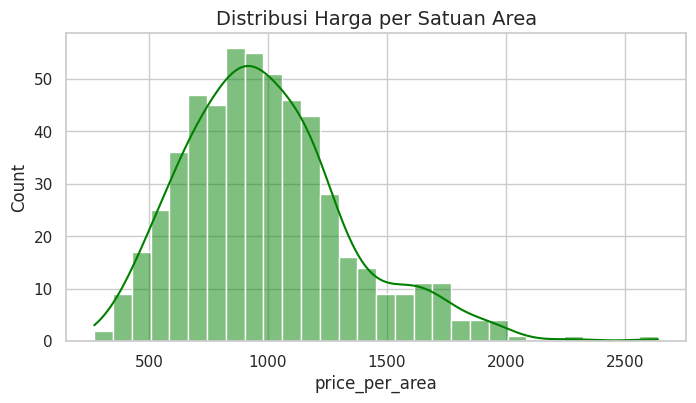

In [10]:
# 1. Membuat fitur baru: price_per_area (Harga per satuan luas)
df['price_per_area'] = df['price'] / df['area']

# 2. Membuat fitur baru: total_rooms (Total ruangan utama di dalam rumah)
# Gabungan dari jumlah kamar tidur, kamar mandi, dan ruang tamu
df['total_rooms'] = df['bedrooms'] + df['bathrooms'] + df['guestroom']

display(df[['price', 'area', 'price_per_area', 'total_rooms']].head())

# Mengecek distribusi price_per_area
plt.figure(figsize=(8, 4))
sns.histplot(df['price_per_area'], bins=30, kde=True, color='green')
plt.title('Distribusi Harga per Satuan Area', fontsize=14)
plt.show()

Insight :

> Fitur baru price_per_area memberikan informasi nilai ekonomis tanah/bangunan. Jika dikombinasikan dengan data lain (misal: lokasi), fitur ini sangat kuat untuk mengetahui apakah sebuah rumah dijual "terlalu murah" atau "terlalu mahal" (overpriced/underpriced) dibandingkan standar area tersebut. Distribusinya terlihat sedikit lebih mendekati normal dibandingkan distribusi harga absolut.

Fitur total_rooms merangkum kapasitas fungsional sebuah rumah. Pembeli sering kali melihat "total kamar" sebagai satu kesatuan ukuran utilitas rumah ketimbang melihat kamar tidur dan kamar mandi secara terpisah.


**8. Kesimpulan**
> Berikan kesimpulan untuk dataset ini dan hasil dari analisis anda terhadap dataset yang dipakai.

> Berdasarkan seluruh proses Data Science yang telah dilakukan pada dataset Housing Prices, dapat ditarik beberapa kesimpulan utama:

Dataset dalam kondisi awal sudah sangat baik (tidak ada data kosong atau duplikat), namun membutuhkan transformasi tipe data (melalui pemetaan biner dan One-Hot Encoding) agar siap digunakan untuk Machine Learning.

Penentu utama harga rumah dalam dataset ini adalah spesifikasi mendasar: luas area (area) dan jumlah kamar mandi (bathrooms).

Fasilitas tambahan memainkan peran yang sangat signifikan terhadap valuasi rumah. Rumah yang memiliki pendingin ruangan (airconditioning) dan telah berperabot penuh (bukan unfurnished) memiliki nilai jual premium di pasar.

Melalui Feature Engineering, pembuatan fitur price_per_area dapat menjadi metrik baru yang berguna bagi model AI tingkat lanjut untuk menilai efisiensi harga properti secara lebih akurat.